# Endowment Economy: Eggertsson & Mehrotra (2014) + Lu (2015)

This notebook replicates the endowment economy results from:

- **Eggertsson & Mehrotra (2014)** "A Model of Secular Stagnation"  
- **Lu (2015)** "Bubbles in a Secular Stagnation Economy"

Sections:
1. [Setup](#1-Setup)
2. [Sanity Check](#2-Sanity-Check)
3. [Loan Market Diagram (EM Figure 1)](#3-Loan-Market-Diagram)
4. [Bubble Effect Diagram (Lu Figure 2)](#4-Bubble-Effect-Diagram)

---
## 1  Setup

In [26]:
import sys
import os

# Make src importable when running from the notebooks/ directory
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), ''))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Calibration constants
import src.calibration as cal

# Endowment model functions
from src.endowment_model import (
    loan_demand,
    loan_supply,
    natural_rate,
    bubble_upper_bound,
    is_bubble_sustainable,
    fundamental_rate,
)

# Figures directory (relative to repo root)
FIG_DIR = os.path.join(os.path.dirname(os.getcwd()), 'figures')
os.makedirs(FIG_DIR, exist_ok=True)

# Plotting defaults
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

# Convenience aliases
BETA  = cal.BETA
D_H   = cal.D        # High collateral constraint (pre-shock)
D_L   = cal.D_L      # Low collateral constraint (post-deleveraging)
G     = cal.G
Y_M   = 1.0          # Middle-aged endowment (normalised)
Y_O   = cal.Y_O

print("Calibration loaded successfully.")
print(f"  beta={BETA}, D_H={D_H}, D_L={D_L}, g={G}, Y_m={Y_M}, Y_o={Y_O}")

Calibration loaded successfully.
  beta=0.77, D_H=0.28, D_L=0.259, g=0.2, Y_m=1.0, Y_o=0.0


---
## 2  Sanity Check

In [27]:
# --- 2a. Fundamental natural rate r^f (EM Table 1 parameters) ----------
R_f = fundamental_rate(D_H, G, Y_M, Y_O, BETA)   # gross rate (1 + r^f)
r_f = R_f - 1.0                                   # net rate

print("Fundamental natural rate (D = D_H, no bubble)")
print(f"  R^f = 1 + r^f = {R_f:.4f}")
print(f"  r^f           = {r_f:.4f}  ({r_f*100:.2f}%)")
print()

Fundamental natural rate (D = D_H, no bubble)
  R^f = 1 + r^f = 1.0727
  r^f           = 0.0727  (7.27%)



In [28]:
# --- 2b. Bubble upper bound A_max at D = D_H ---------------------------
A_max = bubble_upper_bound(Y_M, D_H, BETA)

print("Bubble upper bound (Lu 2015, Proposition 1)")
print(f"  A_max = {A_max:.4f}")
print()

Bubble upper bound (Lu 2015, Proposition 1)
  A_max = -0.0032



In [29]:
# --- 2c. Sustainability check at A = 0, A_max/2, A_max -----------------
for A_test in [0.0, A_max / 2, A_max]:
    ok = is_bubble_sustainable(A_test, Y_M, D_H, BETA)
    print(f"  A = {A_test:.4f}  sustainable: {ok}")
print()

  A = 0.0000  sustainable: False
  A = -0.0016  sustainable: False
  A = -0.0032  sustainable: False



In [30]:
# --- 2d. Verify r^f < g (necessary condition for bubble existence) ------
print("Bubble existence condition: r^f < g")
print(f"  r^f = {r_f:.4f},  g = {G:.4f}")
print(f"  r^f < g : {r_f < G}")

Bubble existence condition: r^f < g
  r^f = 0.0727,  g = 0.2000
  r^f < g : True


---
## 3  Loan Market Diagram

Replicates **EM (2014) Figure 1**.  
Loan demand and supply curves are plotted with the gross real interest rate
$(1+r)$ on the vertical axis and loan quantity $L$ on the horizontal axis.

- **Point A**: equilibrium under $D = D_H$ (pre-shock)
- **Point B**: equilibrium under $D = D_L$ (post-deleveraging shock)

In [31]:
r_vals = np.linspace(-0.3, 0.5, 500)
R_vals = 1.0 + r_vals          # gross interest rate grid

# Loan demand: L^d(r) = (1+g)/(1+r) * D  — one curve per D
LD_H = np.array([loan_demand(D_H, G, r) for r in r_vals])
LD_L = np.array([loan_demand(D_L, G, r) for r in r_vals])

# Loan supply: L^s(r) — same formula for both cases (D_prev = D in each ss)
LS_H = np.array([loan_supply(Y_M, D_H, Y_O, r, BETA) for r in r_vals])
LS_L = np.array([loan_supply(Y_M, D_L, Y_O, r, BETA) for r in r_vals])

# Equilibrium gross rates
R_eq_H = natural_rate(D_H, D_H, G, Y_M, Y_O, BETA)
R_eq_L = natural_rate(D_L, D_L, G, Y_M, Y_O, BETA)

# Equilibrium loan quantities
L_eq_H = loan_demand(D_H, G, R_eq_H - 1.0)
L_eq_L = loan_demand(D_L, G, R_eq_L - 1.0)

print(f"Equilibrium A (D_H): R = {R_eq_H:.4f}, L = {L_eq_H:.4f}")
print(f"Equilibrium B (D_L): R = {R_eq_L:.4f}, L = {L_eq_L:.4f}")

Equilibrium A (D_H): R = 1.0727, L = 0.3132
Equilibrium B (D_L): R = 0.9642, L = 0.3224


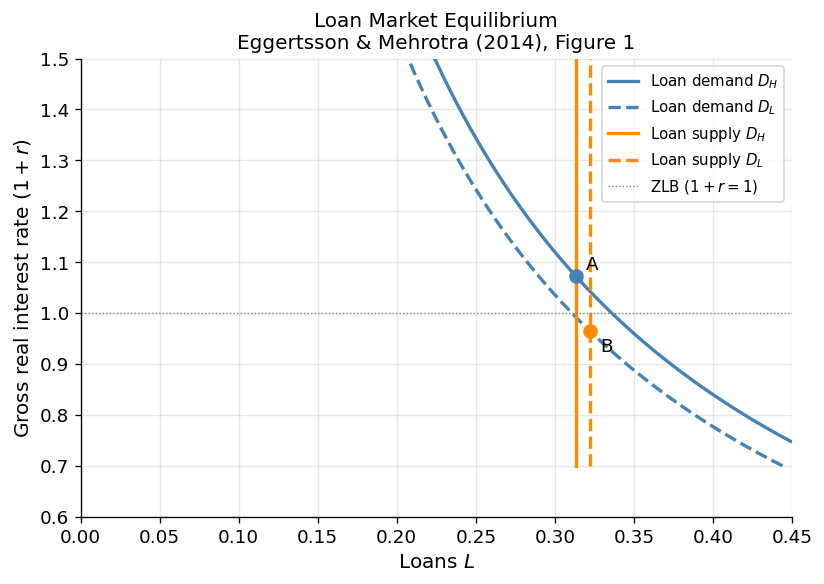

Saved: figures/fig1_loan_market.{pdf,png}


In [32]:
fig, ax = plt.subplots(figsize=(7, 5))

# Clip curves to a sensible loan range for readability
L_lim = (0.0, 0.45)

def plot_curve(ax, L, R, **kwargs):
    """Plot only points where L is within L_lim."""
    mask = (L >= L_lim[0]) & (L <= L_lim[1])
    ax.plot(L[mask], R[mask], **kwargs)

plot_curve(ax, LD_H, R_vals, color='steelblue',  lw=2,   label=r'Loan demand $D_H$')
plot_curve(ax, LD_L, R_vals, color='steelblue',  lw=2,   ls='--', label=r'Loan demand $D_L$')
plot_curve(ax, LS_H, R_vals, color='darkorange', lw=2,   label=r'Loan supply $D_H$')
plot_curve(ax, LS_L, R_vals, color='darkorange', lw=2,   ls='--', label=r'Loan supply $D_L$')

# Equilibrium points
ax.scatter([L_eq_H], [R_eq_H], color='steelblue',  zorder=5, s=60)
ax.scatter([L_eq_L], [R_eq_L], color='darkorange', zorder=5, s=60)
ax.annotate('A', (L_eq_H, R_eq_H), textcoords='offset points', xytext=(6, 4),  fontsize=11)
ax.annotate('B', (L_eq_L, R_eq_L), textcoords='offset points', xytext=(6, -12), fontsize=11)

# Reference line: ZLB (1+r = 1, i.e. r = 0)
ax.axhline(1.0, color='grey', lw=0.8, ls=':', label='ZLB $(1+r=1)$')

ax.set_xlim(*L_lim)
ax.set_ylim(0.6, 1.5)
ax.set_xlabel('Loans $L$', fontsize=12)
ax.set_ylabel('Gross real interest rate $(1+r)$', fontsize=12)
ax.set_title('Loan Market Equilibrium\n'
             'Eggertsson & Mehrotra (2014), Figure 1', fontsize=12)
ax.legend(fontsize=9)

fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'fig1_loan_market.pdf'), bbox_inches='tight')
fig.savefig(os.path.join(FIG_DIR, 'fig1_loan_market.png'), bbox_inches='tight')
plt.show()
print("Saved: figures/fig1_loan_market.{pdf,png}")

---
## 4  Bubble Effect Diagram

Replicates **Lu (2015) Figure 2**.  
The loan supply curve shifts **leftward** as the bubble size $A$ increases,
absorbing saving that would otherwise flow into the loan market.  The
equilibrium gross real interest rate $(1+r)$ rises with $A$.

$D = D_L$ (post-deleveraging) is held fixed throughout.

A_max at D_L=0.259: 0.0297  (should be ~0.0297)


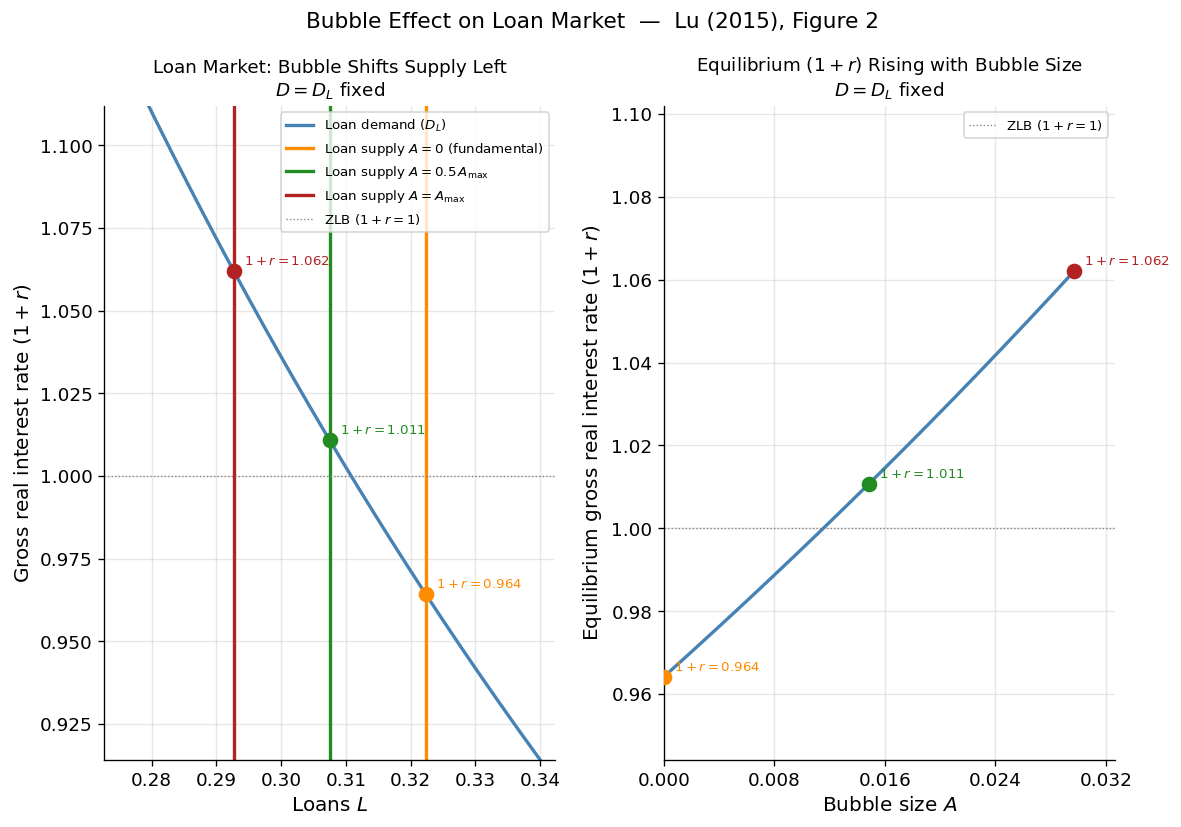

Saved: figures/fig2_bubble_effect.{pdf,png}


In [33]:
# ── Recompute A_max using D_L (Section 4 holds D = D_L fixed) ───────────
A_max_DL = bubble_upper_bound(Y_M, D_L, BETA)
print(f"A_max at D_L={D_L}: {A_max_DL:.4f}  (should be ~0.0297)")
assert A_max_DL > 0, "A_max_DL must be positive for a bubble to exist"

A_vals   = [0.0, A_max_DL * 0.5, A_max_DL]
A_labels = ['$A = 0$ (fundamental)', r'$A = 0.5\,A_{\max}$', r'$A = A_{\max}$']
colors   = ['darkorange', 'forestgreen', 'firebrick']

# ── Pre-compute equilibria for the three discrete A values ───────────────
equil = []
for A in A_vals:
    R_eq = natural_rate(D_L, D_L, G, Y_M, Y_O, BETA, A_bubble=A)
    L_eq = loan_demand(D_L, G, R_eq - 1.0)
    equil.append((R_eq, L_eq))

# Zoom x-axis tightly around the range of equilibrium loan quantities
L_eqs = [e[1] for e in equil]
L_pad = 0.02
L_zoom = (min(L_eqs) - L_pad, max(L_eqs) + L_pad)

# ── Continuous sweep for second panel ────────────────────────────────────
A_sweep = np.linspace(0.0, A_max_DL, 300)
R_sweep = np.array([natural_rate(D_L, D_L, G, Y_M, Y_O, BETA, A_bubble=A)
                    for A in A_sweep])

# ── Figure: two panels side-by-side ──────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 7))

# ── Panel 1: loan market diagram ─────────────────────────────────────────
def plot_curve_zoom(ax, L, R, **kwargs):
    mask = (L >= L_zoom[0]) & (L <= L_zoom[1])
    ax.plot(L[mask], R[mask], **kwargs)

plot_curve_zoom(ax1, LD_L, R_vals, color='steelblue', lw=2,
                label=r'Loan demand ($D_L$)')

for (R_eq, L_eq), A, label, color in zip(equil, A_vals, A_labels, colors):
    LS = np.array([loan_supply(Y_M, D_L, Y_O, r, BETA, A_bubble=A)
                   for r in r_vals])
    plot_curve_zoom(ax1, LS, R_vals, color=color, lw=2,
                    label=f'Loan supply {label}')
    ax1.scatter([L_eq], [R_eq], color=color, zorder=5, s=70)
    ax1.annotate(f'$1+r={R_eq:.3f}$', (L_eq, R_eq),
                 textcoords='offset points', xytext=(6, 4),
                 fontsize=8, color=color)

ax1.axhline(1.0, color='grey', lw=0.8, ls=':', label='ZLB $(1+r=1)$')
ax1.set_xlim(*L_zoom)
R_all = [e[0] for e in equil]
ax1.set_ylim(min(R_all) - 0.05, max(R_all) + 0.05)
ax1.set_xlabel('Loans $L$', fontsize=12)
ax1.set_ylabel('Gross real interest rate $(1+r)$', fontsize=12)
ax1.set_title('Loan Market: Bubble Shifts Supply Left\n$D = D_L$ fixed', fontsize=11)
ax1.legend(fontsize=8, loc='upper right')

# ── Panel 2: equilibrium (1+r) vs bubble size A ──────────────────────────
ax2.plot(A_sweep, R_sweep, color='steelblue', lw=2)
ax2.axhline(1.0, color='grey', lw=0.8, ls=':', label='ZLB $(1+r=1)$')

for (R_eq, _), A, color in zip(equil, A_vals, colors):
    ax2.scatter([A], [R_eq], color=color, zorder=5, s=70)
    ax2.annotate(f'$1+r={R_eq:.3f}$', (A, R_eq),
                 textcoords='offset points', xytext=(6, 4),
                 fontsize=8, color=color)

ax2.set_xlim(0, A_max_DL * 1.1)
ax2.xaxis.set_major_locator(mticker.MaxNLocator(5))
ax2.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))
R_all2 = [e[0] for e in equil]
ax2.set_ylim(min(R_all2) - 0.02, max(R_all2) + 0.04)
ax2.set_xlabel('Bubble size $A$', fontsize=12)
ax2.set_ylabel('Equilibrium gross real interest rate $(1+r)$', fontsize=12)
ax2.set_title('Equilibrium $(1+r)$ Rising with Bubble Size\n$D = D_L$ fixed', fontsize=11)
ax2.legend(fontsize=8)

fig.suptitle('Bubble Effect on Loan Market  —  Lu (2015), Figure 2', fontsize=13)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'fig2_bubble_effect.pdf'), bbox_inches='tight')
fig.savefig(os.path.join(FIG_DIR, 'fig2_bubble_effect.png'), bbox_inches='tight')
plt.show()
print("Saved: figures/fig2_bubble_effect.{pdf,png}")